In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
from functools import reduce
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [34]:
df_env = pd.read_csv('/Users/andydascikid/Downloads/Environmental Dataset.csv')
df_ndti = pd.read_csv('/Users/andydascikid/Python Scripts/Home/Yamuna Water Analysis/CSV Files/NDTI_Interpolated.csv')
df_ndci = pd.read_csv('/Users/andydascikid/Python Scripts/Home//Yamuna Water Analysis/CSV Files/NDCI_Interpolated.csv')

In [35]:
df_env["Date"] = pd.to_datetime(df_env["Date"])
df_env["Date"] = df_env["Date"].dt.strftime("%Y-%m-%d")

df_ndti["Date"] = pd.to_datetime(df_ndti["Date"])
df_ndti["Date"] = df_ndti["Date"].dt.strftime("%Y-%m-%d")

df_ndci["Date"] = pd.to_datetime(df_ndci["Date"])
df_ndci["Date"] = df_ndci["Date"].dt.strftime("%Y-%m-%d")

In [36]:
df_env = df_env[df_env["Date"].between('2020-01-01', '2025-12-20')]
df_ndti = df_ndti[df_ndti["Date"].between('2020-01-01', '2025-12-20')]
df_ndci = df_ndci[df_ndci["Date"].between('2020-01-01', '2025-12-20')]

In [37]:
def stack_csv_columns(file_list, common_column):
    # 1. Read all CSV files into a list of DataFrames
    dfs = file_list

    # 2. Sequentially merge the DataFrames side-by-side on the common column
    # how='outer' ensures no rows are dropped if an ID is missing in one file
    final_df = reduce(
        lambda left, right: pd.merge(
            left, right, on=common_column, how="outer"
        ),
        dfs,
    )
    output_filename = "Compiled DataSet.csv"
    final_df.to_csv(output_filename, index=False)
    print(f"Success! Saved combined files to '{output_filename}'")
    return final_df

csv_files = [df_env, df_ndti, df_ndci]

# Specify the exact name of the column present in all files (e.g., 'ID', 'Date', etc.)
shared_column = "Date"

stack_csv_columns(csv_files, shared_column)

Success! Saved combined files to 'Compiled DataSet.csv'


,Date,Rainfall (mm),Air Temp (Celcius),Wind Speed (m/s),Relative Humidity (%),Solar Radiation (MJ/m2),Water Surface Temp (C),mean_NDTI,mean_NDCI
0,2020-01-01,0.000000,10.620942,1.809638,72.977856,13395416.00,14.042350,-0.02891,0.07160
1,2020-01-02,0.000000,14.049093,2.256785,74.385434,13285615.50,16.353560,-0.02869,0.07220
2,2020-01-03,2.208222,14.430825,0.508545,75.774544,12764878.25,17.218774,-0.02846,0.07280
3,2020-01-04,0.000000,13.751288,1.296588,73.477940,12650305.75,17.336042,-0.02823,0.07340
4,2020-01-05,0.000000,14.167369,2.172828,68.969071,14080280.75,17.453310,-0.02800,0.07400
...,...,...,...,...,...,...,...,...,...
2176,2025-12-16,0.000000,16.567571,3.223076,68.243159,14250022.50,16.564957,0.50200,-0.06300
2177,2025-12-17,0.000000,16.307450,2.716081,68.219267,14194777.75,17.717978,0.43288,-0.05412
2178,2025-12-18,0.000000,15.285533,1.788904,77.905019,13342228.50,16.282916,0.36375,-0.04525
2179,2025-12-19,0.000000,15.250582,2.332101,71.995010,13890053.75,14.847853,0.29462,-0.03637


In [38]:
dataset = stack_csv_columns(csv_files, shared_column).drop(columns='Date')
dataset = dataset.drop(columns='mean_NDCI')

Success! Saved combined files to 'Compiled DataSet.csv'


In [39]:
df = dataset.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)

pc_columns = [f'PC{i+1}' for i in range(7)]
df_pca = pd.DataFrame(data=X_pca, columns=pc_columns)

plt.figure(figsize=(12, 5))

exp_var_ratio = pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(exp_var_ratio)

<Figure size 1200x500 with 0 Axes>

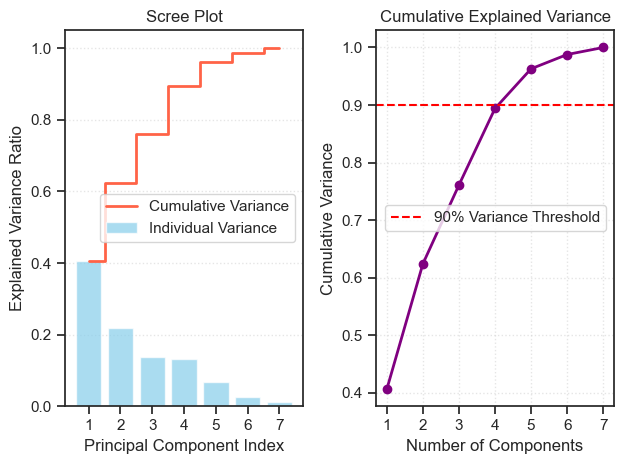

In [40]:
# Left Subplot: Individual Variance Bars
plt.subplot(1, 2, 1)
plt.bar(range(1, 8), exp_var_ratio, alpha=0.7, align='center', label='Individual Variance', color='skyblue')
plt.step(range(1, 8), cum_var_ratio, where='mid', label='Cumulative Variance', color='tomato', linewidth=2)
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot')
plt.xticks(range(1, 8))
plt.legend(loc='best')
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Right Subplot: Cumulative Variance Elbow Chart
plt.subplot(1, 2, 2)
plt.plot(range(1, 8), cum_var_ratio, marker='o', color='purple', linewidth=2)
plt.axhline(y=0.90, color='red', linestyle='--', label='90% Variance Threshold')
plt.ylabel('Cumulative Variance')
plt.xlabel('Number of Components')
plt.title('Cumulative Explained Variance')
plt.xticks(range(1, 8))
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


Generating pairwise PCA plots...


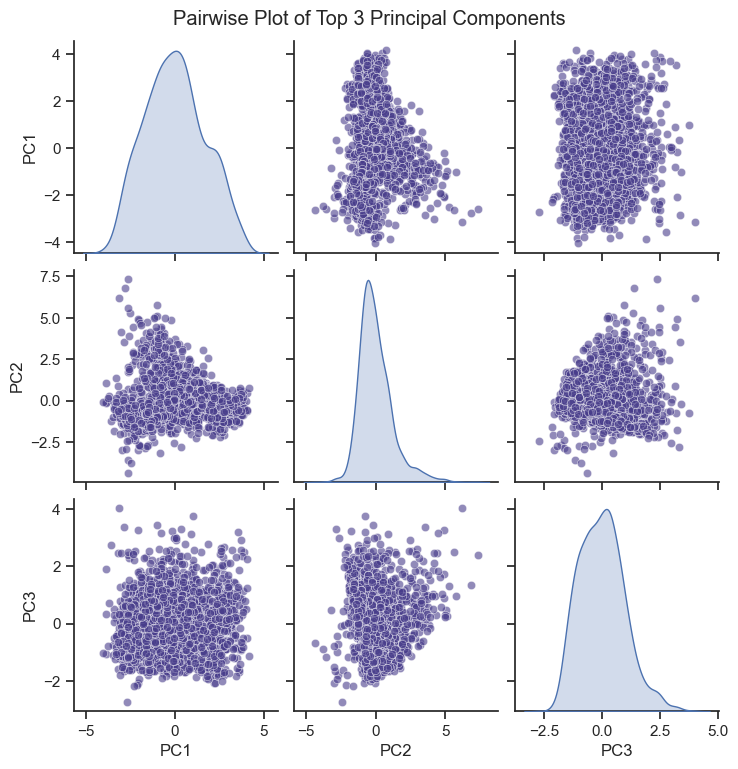

In [41]:
print("Generating pairwise PCA plots...")
sns.set_theme(style="ticks")
pair_grid = sns.pairplot(df_pca[['PC1', 'PC2', 'PC3']], diag_kind='kde', plot_kws={'alpha': 0.6, 'color': 'darkslateblue'})
pair_grid.fig.suptitle('Pairwise Plot of Top 3 Principal Components', y=1.02)
plt.show()


In [42]:
print("\n" + "="*50)
print("VARIANCE EXPLAINED PER COMPONENT")
print("="*50)
for i, (var, cum) in enumerate(zip(exp_var_ratio, cum_var_ratio)):
    print(f"PC{i+1}: explains {var*100:.2f}% (Cumulative: {cum*100:.2f}%)")


VARIANCE EXPLAINED PER COMPONENT
PC1: explains 40.61% (Cumulative: 40.61%)
PC2: explains 21.79% (Cumulative: 62.40%)
PC3: explains 13.69% (Cumulative: 76.09%)
PC4: explains 13.31% (Cumulative: 89.40%)
PC5: explains 6.89% (Cumulative: 96.30%)
PC6: explains 2.48% (Cumulative: 98.78%)
PC7: explains 1.22% (Cumulative: 100.00%)


In [43]:
optimal_pcs = np.argmax(cum_var_ratio >= 0.90) + 1
X_reduced = df_pca.iloc[:, :optimal_pcs]

print(f"\n[INFO] To capture 90%+ variance, retain the first {optimal_pcs} components.")
print("\nFirst 5 rows of your final modeling dataset:")
print(X_reduced.head())


[INFO] To capture 90%+ variance, retain the first 5 components.

First 5 rows of your final modeling dataset:
        PC1       PC2       PC3       PC4       PC5
0 -2.811038 -1.149823 -0.221759 -0.517058  0.510175
1 -2.379996 -0.940447  0.205951 -0.365660  0.102402
2 -2.500438 -0.140258 -1.298348 -0.332571  0.439598
3 -2.416957 -0.622451 -0.665531 -0.397661  0.223328
4 -2.069861 -1.000173  0.106116 -0.342652  0.256621
